# Modelo Random Forest

## Importar librerías

In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

## Cargando la tabla limpia

In [25]:
df = pd.read_csv("archive/processed/diabetes_clean.csv")

In [26]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Risk_Group
0,0,1,1,1,40.0,1,0,0,0,0,...,0,5,18.0,15.0,1,0,9,4,3,0
1,0,0,0,0,25.0,1,0,0,1,0,...,1,3,0.0,0.0,0,0,7,6,1,0
2,0,1,1,1,28.0,0,0,0,0,1,...,1,5,30.0,30.0,1,0,9,4,8,0
3,0,1,0,1,27.0,0,0,0,1,1,...,0,2,0.0,0.0,0,0,11,3,6,0
4,0,1,1,1,24.0,0,0,0,1,1,...,0,2,3.0,0.0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229776,0,1,1,1,45.0,0,0,0,0,1,...,0,3,0.0,5.0,0,1,5,6,7,0
229777,2,1,1,1,18.0,0,0,0,0,0,...,0,4,0.0,0.0,1,0,11,2,4,1
229778,0,0,0,1,28.0,0,0,0,1,1,...,0,1,0.0,0.0,0,0,2,5,2,0
229779,0,1,0,1,23.0,0,0,0,0,1,...,0,3,0.0,0.0,0,1,7,5,1,0


### Train test Split

In [27]:
# Creando features y target para mi modelo 
features = df.drop(["Diabetes_012","Risk_Group"], axis=1)
target= df["Risk_Group"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    stratify= target,
    random_state=42)

### Modelo Random Forest con class_weight='balanced'

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [32]:
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# Predicciones
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.93      0.73      0.82     38012
           1       0.36      0.74      0.49      7945

    accuracy                           0.73     45957
   macro avg       0.65      0.73      0.65     45957
weighted avg       0.83      0.73      0.76     45957

ROC-AUC: 0.8111667479124707


In [35]:
# Optimización de threshold (max F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_threshold = thresholds[np.argmax(f1)]

best_index = np.argmax(f1)
best_threshold = thresholds[best_index]

print("\nMejor threshold:", round(best_threshold, 4))
print("Mejor F1:", round(f1[best_index], 4))


Mejor threshold: 0.6079
Mejor F1: 0.4966


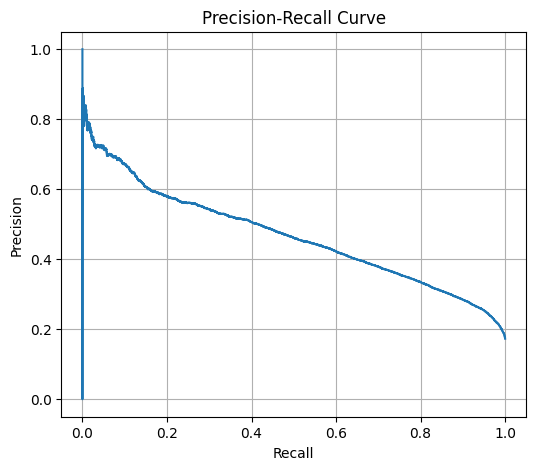

In [36]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

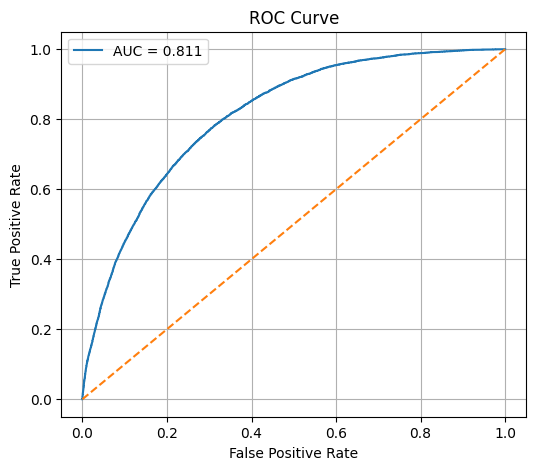

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [38]:
y_pred_custom = (y_probs > best_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87     38012
           1       0.43      0.59      0.50      7945

    accuracy                           0.79     45957
   macro avg       0.67      0.71      0.68     45957
weighted avg       0.82      0.79      0.81     45957

